Import the necessary libraries

In [362]:
import sqlite3
import pandas as pd
import seaborn as sns
import numpy as np
import re as re
from matplotlib import pyplot as plt
pd.options.display.max_rows = 999
pd.options.display.max_columns = 90

Load the dataset into sqlite3

In [363]:
con = sqlite3.connect("bmarket.db")


In [364]:
cursor = con.cursor()

        # Query the sqlite_master table to get table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        
        # Fetch all results
table_names = [row[0] for row in cursor.fetchall()]

In [365]:
print(table_names)

['bank_marketing']


In [366]:
query = "SELECT * FROM bank_marketing"  # Replace 'your_table_name' with the actual table name
df = pd.read_sql_query(query, con)
df.head(10)

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57 years,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,Cell,2,999,no
5,17202,58 years,retired,married,professional.course,no,None,yes,Cell,1,999,no
6,880,48 years,services,married,high.school,unknown,yes,no,Telephone,1,999,no
7,23758,150 years,admin.,divorced,university.degree,unknown,yes,None,Cell,7,999,no
8,10822,24 years,entrepreneur,married,university.degree,no,None,None,telephone,4,999,no
9,14356,36 years,technician,divorced,professional.course,no,yes,yes,Cell,4,999,no


In [367]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client ID              41188 non-null  int64 
 1   Age                    41188 non-null  object
 2   Occupation             41188 non-null  object
 3   Marital Status         41188 non-null  object
 4   Education Level        41188 non-null  object
 5   Credit Default         41188 non-null  object
 6   Housing Loan           16399 non-null  object
 7   Personal Loan          37042 non-null  object
 8   Contact Method         41188 non-null  object
 9   Campaign Calls         41188 non-null  int64 
 10  Previous Contact Days  41188 non-null  int64 
 11  Subscription Status    41188 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.8+ MB


In [368]:
for col in df.columns:
    print(f"\n🔹 {col} — {df[col].nunique()} unique values:")
    print(df[col].unique())


🔹 Client ID — 41188 unique values:
[32885  3170 32207 ... 38159   861 15796]

🔹 Age — 77 unique values:
['57 years' '55 years' '33 years' '36 years' '27 years' '58 years'
 '48 years' '150 years' '24 years' '34 years' '42 years' '43 years'
 '26 years' '37 years' '46 years' '59 years' '49 years' '30 years'
 '51 years' '45 years' '31 years' '41 years' '38 years' '47 years'
 '69 years' '50 years' '25 years' '39 years' '44 years' '52 years'
 '35 years' '77 years' '40 years' '56 years' '53 years' '60 years'
 '29 years' '28 years' '54 years' '32 years' '81 years' '63 years'
 '21 years' '22 years' '74 years' '80 years' '62 years' '68 years'
 '86 years' '23 years' '71 years' '67 years' '65 years' '20 years'
 '19 years' '66 years' '75 years' '18 years' '72 years' '70 years'
 '82 years' '85 years' '61 years' '88 years' '83 years' '78 years'
 '64 years' '17 years' '76 years' '73 years' '79 years' '89 years'
 '84 years' '91 years' '98 years' '92 years' '95 years']

🔹 Occupation — 12 unique values:

In [369]:
df = df.applymap(lambda x: x.strip().lower() if isinstance(x, str) else x)

C:\Users\tan98\AppData\Local\Temp\ipykernel_32708\1274793226.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip().lower() if isinstance(x, str) else x)


In [370]:
def to_snake(name):
    return re.sub(r'[\s\.-]+', '_', name.strip().lower())

df = df.rename(columns=lambda c: to_snake(c))
df

,client_id,age,occupation,marital_status,education_level,credit_default,housing_loan,personal_loan,contact_method,campaign_calls,previous_contact_days,subscription_status
0,32885,57 years,technician,married,high.school,no,no,yes,cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,cell,2,999,no
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58 years,retired,married,professional.course,unknown,no,no,telephone,2,999,no
41184,11285,37 years,management,married,university.degree,no,no,no,telephone,1,999,no
41185,38159,35 years,admin.,married,high.school,no,None,no,cellular,1,4,yes
41186,861,40 years,management,married,university.degree,no,None,no,telephone,2,999,no


In [371]:
df.isna().sum()

client_id                    0
age                          0
occupation                   0
marital_status               0
education_level              0
credit_default               0
housing_loan             24789
personal_loan             4146
contact_method               0
campaign_calls               0
previous_contact_days        0
subscription_status          0
dtype: int64

In [372]:
# Remove the word 'years' from the 'age' column and convert to numeric
if 'age' in df.columns:
    df['age'] = (
        df['age']
        .astype(str)
        .str.replace('years', '', case=False)
        .str.strip()
    )
    df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Verify change
df['age'].value_counts(dropna=False)

age
150    4197
31     1747
32     1646
33     1643
36     1606
35     1584
34     1577
30     1536
37     1345
29     1310
38     1283
39     1281
41     1142
40     1027
42     1020
45      979
43      950
46      920
44      892
28      892
48      875
47      833
50      778
27      765
49      758
52      689
51      676
53      654
56      636
26      630
54      628
57      597
55      589
25      536
58      511
24      414
59      409
60      254
23      207
22      123
21       90
61       66
20       62
62       55
64       55
66       54
63       50
71       47
65       42
70       40
19       38
73       33
69       32
68       31
76       30
74       30
72       30
80       29
18       27
78       23
67       21
75       20
88       19
77       18
81       16
83       16
82       16
85       15
79       13
86        8
84        7
17        5
92        4
89        2
91        2
98        2
95        1
Name: count, dtype: int64

In [373]:
df["occupation"] = df["occupation"].astype(str).str.replace(".", "", regex=False)
df['occupation'] = df['occupation'].astype(str).str.replace("-", "_", regex=False)
df["occupation"].value_counts(dropna=False)

occupation
admin            10422
blue_collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self_employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [374]:
df["education_level"] = df["education_level"].astype(str).str.replace(".", "_", regex=False)
df["education_level"].value_counts(dropna=False)

education_level
university_degree      12168
high_school             9515
basic_9y                6045
professional_course     5243
basic_4y                4176
basic_6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [375]:
# Standarize the 
if 'contact_method' in df.columns:
    df['contact_method'] = df['contact_method'].replace(['cell'], 'cellular')
    df['contact_method'] = df['contact_method'].replace(['Telephone'], 'telephone')

# Check if replacement worked
df['contact_method'].value_counts()

contact_method
cellular     26144
telephone    15044
Name: count, dtype: int64

In [376]:
df.loc[df['campaign_calls'] < 0, 'campaign_calls'] = 0
df['campaign_calls'].value_counts(dropna=False)

campaign_calls
1     15874
2      9446
3      4807
0      4153
4      2405
5      1451
6       893
7       566
8       365
9       253
10      206
11      156
12      107
13       84
14       58
17       51
15       47
16       46
18       30
20       27
19       24
21       22
24       15
22       14
23       11
27       11
29        9
26        8
30        7
25        7
31        7
28        6
33        4
32        3
34        3
35        3
42        2
40        2
43        2
56        1
39        1
37        1
Name: count, dtype: int64

In [451]:
df['subscription_status'].value_counts(dropna=False)

subscription_status
no     36548
yes     4640
Name: count, dtype: int64

Change all the unknown value to NULL

In [377]:
df = df.replace("unknown", np.nan)
df = df.replace({None: np.nan})
df["previous_contact_days"] = df["previous_contact_days"].replace(999, np.nan)
df["age"] = df["age"].replace(150, np.nan)

In [378]:
for col in df.columns:
    print(f"\n🔹 {col} — {df[col].nunique()} unique values:")
    print(df[col].unique())


🔹 client_id — 41188 unique values:
[32885  3170 32207 ... 38159   861 15796]

🔹 age — 76 unique values:
[57. 55. 33. 36. 27. 58. 48. nan 24. 34. 42. 43. 26. 37. 46. 59. 49. 30.
 51. 45. 31. 41. 38. 47. 69. 50. 25. 39. 44. 52. 35. 77. 40. 56. 53. 60.
 29. 28. 54. 32. 81. 63. 21. 22. 74. 80. 62. 68. 86. 23. 71. 67. 65. 20.
 19. 66. 75. 18. 72. 70. 82. 85. 61. 88. 83. 78. 64. 17. 76. 73. 79. 89.
 84. 91. 98. 92. 95.]

🔹 occupation — 11 unique values:
['technician' nan 'blue_collar' 'admin' 'housemaid' 'retired' 'services'
 'entrepreneur' 'unemployed' 'management' 'self_employed' 'student']

🔹 marital_status — 3 unique values:
['married' 'divorced' 'single' nan]

🔹 education_level — 7 unique values:
['high_school' nan 'basic_9y' 'professional_course' 'university_degree'
 'basic_4y' 'basic_6y' 'illiterate']

🔹 credit_default — 2 unique values:
['no' nan 'yes']

🔹 housing_loan — 2 unique values:
['no' 'yes' nan]

🔹 personal_loan — 2 unique values:
['yes' 'no' nan]

🔹 contact_method — 2 uniq

In [379]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   client_id              41188 non-null  int64  
 1   age                    36991 non-null  float64
 2   occupation             40858 non-null  object 
 3   marital_status         41108 non-null  object 
 4   education_level        39457 non-null  object 
 5   credit_default         32591 non-null  object 
 6   housing_loan           16006 non-null  object 
 7   personal_loan          36165 non-null  object 
 8   contact_method         41188 non-null  object 
 9   campaign_calls         41188 non-null  int64  
 10  previous_contact_days  1515 non-null   float64
 11  subscription_status    41188 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 3.8+ MB


In [380]:
df.isna().sum()

client_id                    0
age                       4197
occupation                 330
marital_status              80
education_level           1731
credit_default            8597
housing_loan             25182
personal_loan             5023
contact_method               0
campaign_calls               0
previous_contact_days    39673
subscription_status          0
dtype: int64

Age Imputation

<Figure size 1400x600 with 0 Axes>

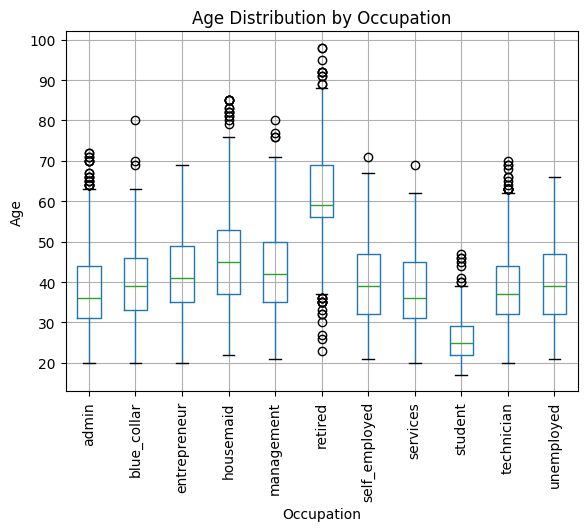

In [381]:
plt.figure(figsize=(14,6))
df.boxplot(column="age", by="occupation", rot=90)
plt.title("Age Distribution by Occupation")
plt.suptitle("")   # removes automatic title
plt.xlabel("Occupation")
plt.ylabel("Age")
plt.show()


<Figure size 800x500 with 0 Axes>

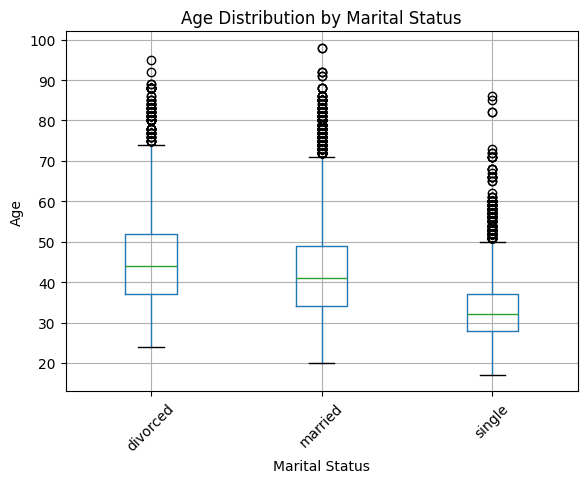

In [382]:
plt.figure(figsize=(8,5))
df.boxplot(column="age", by="marital_status", rot=45)
plt.title("Age Distribution by Marital Status")
plt.suptitle("")
plt.xlabel("Marital Status")
plt.ylabel("Age")
plt.show()


<Figure size 1000x500 with 0 Axes>

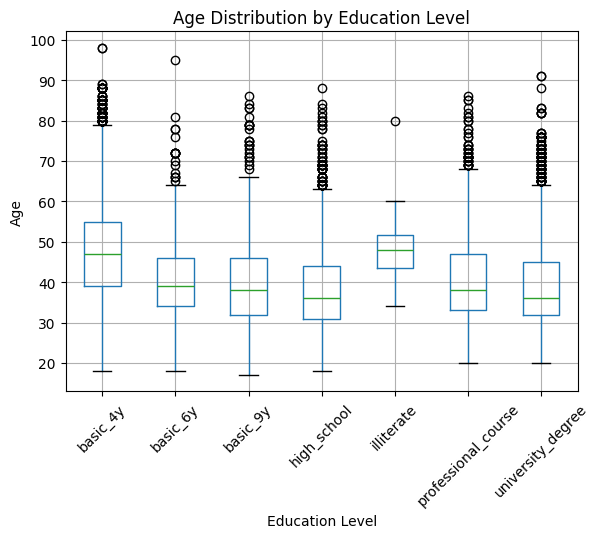

In [383]:
plt.figure(figsize=(10,5))
df.boxplot(column="age", by="education_level", rot=45)
plt.title("Age Distribution by Education Level")
plt.suptitle("")
plt.xlabel("Education Level")
plt.ylabel("Age")
plt.show()

In [384]:
def impute_age_special(df, age_col="age", occ_col="occupation", ms_col="marital_status"):
    """
    Impute NULLs in `age` using staged medians:
      Stage A: median by (occupation, marital_status)
      Stage B: median by (occupation)
      Stage C: global median

    Assumes:
      - `age` is already numeric
      - invalid ages like 150 already replaced with NaN
    Returns:
      df_out, report_dict
    """
    out = df.copy()

    # Ensure numeric age
    out[age_col] = pd.to_numeric(out[age_col], errors="coerce")

    # Normalize grouping keys (similar style to occupation imputation)
    for c in [occ_col, ms_col]:
        if c in out.columns:
            out[c] = (
                out[c]
                .astype(str)
                .str.strip()
                .str.lower()
                .replace({"": np.nan, "nan": np.nan})
            )

    before_missing = int(out[age_col].isna().sum())

    def gmedian(s: pd.Series):
        s = s.dropna()
        return float(s.median()) if not s.empty else np.nan

    report = {}

    # ---------- Stage A: (occupation, marital_status) ----------
    missing = out[age_col].isna()
    if missing.sum() > 0:
        medA = (
            out.groupby([occ_col, ms_col])[age_col]
               .apply(gmedian)
               .rename("__med")
               .reset_index()
        )
        out = out.merge(medA, on=[occ_col, ms_col], how="left")
        fillA = missing & out["__med"].notna()
        out.loc[fillA, age_col] = out.loc[fillA, "__med"]
        out = out.drop(columns="__med")
        report["filled_stage_A"] = int(fillA.sum())
    else:
        report["filled_stage_A"] = 0

    # ---------- Stage B: (occupation) ----------
    missing = out[age_col].isna()
    if missing.sum() > 0:
        medB = (
            out.groupby([occ_col])[age_col]
               .apply(gmedian)
               .rename("__med")
               .reset_index()
        )
        out = out.merge(medB, on=[occ_col], how="left")
        fillB = missing & out["__med"].notna()
        out.loc[fillB, age_col] = out.loc[fillB, "__med"]
        out = out.drop(columns="__med")
        report["filled_stage_B"] = int(fillB.sum())
    else:
        report["filled_stage_B"] = 0

    # ---------- Stage C: global median ----------
    missing = out[age_col].isna()
    if missing.sum() > 0:
        global_med = gmedian(out[age_col])
        out.loc[missing, age_col] = global_med
        report["filled_stage_C"] = int(missing.sum())
    else:
        report["filled_stage_C"] = 0

    after_missing = int(out[age_col].isna().sum())
    report["age_missing_before"] = before_missing
    report["age_missing_after"] = after_missing

    # Optional: see what ages were assigned for originally-missing rows
    originally_missing = df[age_col].isna()
    assigned = out.loc[originally_missing, age_col].value_counts().head(10)
    report["top_assigned_ages"] = assigned.to_dict()

    # Use nullable integer for nice display (no .0)
    out[age_col] = out[age_col].round().astype("Int64")

    return out, report

In [385]:
df, age_report = impute_age_special(df)

print("=== Age Imputation Report ===")
for k, v in age_report.items():
    print(k, ":", v)


=== Age Imputation Report ===
filled_stage_A : 4157
filled_stage_B : 9
filled_stage_C : 31
age_missing_before : 4197
age_missing_after : 0
top_assigned_ages : {39.0: 1196, 32.0: 931, 40.0: 681, 43.0: 361, 42.0: 330, 41.0: 169, 59.0: 164, 31.0: 118, 46.0: 70, 25.0: 63}


In [386]:
df['age'].value_counts(dropna=False)

age
32    2577
39    2477
31    1865
40    1708
33    1643
36    1608
34    1602
35    1584
30    1536
37    1360
42    1350
43    1311
41    1311
29    1310
38    1283
46     990
45     979
28     892
44     892
48     875
47     870
50     804
27     765
49     758
52     689
51     676
53     654
56     636
26     630
54     628
57     606
25     599
55     589
59     573
58     511
24     414
60     254
23     207
22     123
21      90
61      66
20      62
62      55
64      55
66      54
63      50
71      47
65      42
70      40
19      38
73      33
69      32
68      31
76      30
74      30
72      30
80      29
18      27
78      23
67      21
75      20
88      19
77      18
81      16
83      16
82      16
85      15
79      13
86       8
84       7
17       5
92       4
89       2
91       2
98       2
95       1
Name: count, dtype: Int64

Occupation Imputation

In [387]:
pd.crosstab(
    df["education_level"],
    df["occupation"],
    normalize="index"
).round(3) * 100


occupation,admin,blue_collar,entrepreneur,housemaid,management,retired,self_employed,services,student,technician,unemployed
education_level,,,,,,,,,,,
basic_4y,1.9,56.2,3.3,11.5,2.4,14.5,2.3,3.2,0.6,1.4,2.7
basic_6y,6.7,62.8,3.1,3.4,3.7,3.3,1.1,10.0,0.6,3.8,1.5
basic_9y,8.3,60.2,3.5,1.6,2.8,2.4,3.7,6.5,1.6,6.4,3.1
high_school,35.1,9.3,2.5,1.8,3.1,2.9,1.2,28.3,3.8,9.2,2.7
illiterate,5.6,44.4,11.1,5.6,0.0,16.7,16.7,0.0,0.0,0.0,0.0
professional_course,6.9,8.7,2.6,1.1,1.7,4.6,3.2,4.2,0.8,63.5,2.7
university_degree,47.5,0.8,5.0,1.1,17.0,2.4,6.3,1.4,1.4,14.9,2.2


In [388]:
pd.crosstab(
    df["marital_status"],
    df["occupation"],
    normalize="index"
).round(3) * 100


occupation,admin,blue_collar,entrepreneur,housemaid,management,retired,self_employed,services,student,technician,unemployed
marital_status,,,,,,,,,,,
divorced,27.8,15.8,3.9,3.5,7.2,7.6,2.9,11.6,0.2,16.8,2.7
married,21.3,27.1,4.3,3.1,8.5,5.2,3.7,9.3,0.2,14.9,2.6
single,33.7,15.9,1.8,1.0,4.4,0.8,3.3,9.9,7.2,19.9,2.2


<Figure size 1600x600 with 0 Axes>

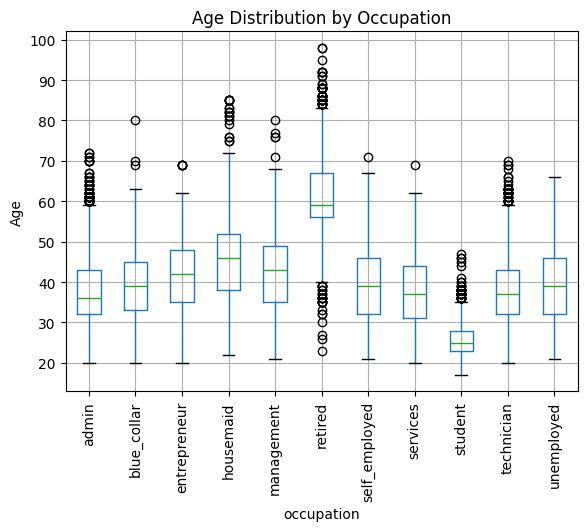

In [389]:
plt.figure(figsize=(16,6))
df.boxplot(column="age", by="occupation", rot=90)
plt.title("Age Distribution by Occupation")
plt.suptitle("")
plt.ylabel("Age")
plt.show()

In [390]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, float("inf")],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"],
    right=False
)


In [391]:
def impute_occupation_with_stage(
    df,
    occ_col="occupation",
    edu_col="education_level",
    agegrp_col="age_group"
):
    """
    Staged occupation imputation using:
      Stage A: (education_level + age_group)
      Stage B: (education_level)
      Stage C: global mode

    Adds a column 'occupation_impute_stage' with values:
      'A', 'B', 'C' for imputed rows
      None / NaN for rows that were not imputed.
    """

    out = df.copy()

    # track which rows were originally missing
    orig_missing = out[occ_col].isna()

    # clean text columns
    for c in [occ_col, edu_col, agegrp_col]:
        if c in out.columns:
            out[c] = (
                out[c]
                .astype(str)
                .str.strip()
                .str.lower()
                .replace({"": np.nan, "nan": np.nan})
            )

    before_missing = int(out[occ_col].isna().sum())
    out["occupation_impute_stage"] = np.nan  # mark stages here

    def gmode(s: pd.Series):
        s = s.dropna()
        return s.mode().iloc[0] if not s.empty else np.nan

    report = {}

    # ---------- Stage A: edu + age_group ----------
    missing = out[occ_col].isna()
    if missing.sum() > 0:
        modA = (
            out.groupby([edu_col, agegrp_col])[occ_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modA, on=[edu_col, agegrp_col], how="left")
        fillA = missing & out["__mod"].notna()
        out.loc[fillA, occ_col] = out.loc[fillA, "__mod"]
        # label stage for rows that were originally missing
        out.loc[fillA & orig_missing, "occupation_impute_stage"] = "A"
        out = out.drop(columns="__mod")
        report["filled_stage_A"] = int(fillA.sum())
    else:
        report["filled_stage_A"] = 0

    # ---------- Stage B: edu only ----------
    missing = out[occ_col].isna()
    if missing.sum() > 0:
        modB = (
            out.groupby([edu_col])[occ_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modB, on=[edu_col], how="left")
        fillB = missing & out["__mod"].notna()
        out.loc[fillB, occ_col] = out.loc[fillB, "__mod"]
        out.loc[fillB & orig_missing, "occupation_impute_stage"] = "B"
        out = out.drop(columns="__mod")
        report["filled_stage_B"] = int(fillB.sum())
    else:
        report["filled_stage_B"] = 0

    # ---------- Stage C: global mode ----------
    missing = out[occ_col].isna()
    if missing.sum() > 0:
        global_mod = gmode(out[occ_col])
        out.loc[missing, occ_col] = global_mod
        out.loc[missing & orig_missing, "occupation_impute_stage"] = "C"
        report["filled_stage_C"] = int(missing.sum())
    else:
        report["filled_stage_C"] = 0

    after_missing = int(out[occ_col].isna().sum())
    report["occupation_missing_before"] = before_missing
    report["occupation_missing_after"] = after_missing

    return out, report, orig_missing


In [392]:
# run imputation
df, occ_report, orig_missing_mask = impute_occupation_with_stage(df)

print("=== Occupation Imputation Report ===")
for k, v in occ_report.items():
    print(k, ":", v)


=== Occupation Imputation Report ===
filled_stage_A : 199
filled_stage_B : 0
filled_stage_C : 131
occupation_missing_before : 330
occupation_missing_after : 0


C:\Users\tan98\AppData\Local\Temp\ipykernel_32708\990829146.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[fillA & orig_missing, "occupation_impute_stage"] = "A"


In [393]:
assigned_rows = df.loc[orig_missing_mask, 
    ["age", "age_group", "education_level", "occupation", "occupation_impute_stage"]
]

print(assigned_rows.head(20))  # see first 20


      age age_group      education_level   occupation occupation_impute_stage
1      55     55-64                  NaN        admin                       C
22     26     25-34          high_school        admin                       A
29     38     35-44          high_school        admin                       A
334    34     25-34    university_degree        admin                       A
535    59     55-64                  NaN        admin                       C
746    52     45-54  professional_course   technician                       A
1001   35     35-44             basic_9y  blue_collar                       A
1175   38     35-44                  NaN        admin                       C
1364   36     35-44                  NaN        admin                       C
1556   39     35-44                  NaN        admin                       C
1591   24       <25    university_degree        admin                       A
1634   47     45-54                  NaN        admin           

Marital_status imputation

<Figure size 800x500 with 0 Axes>

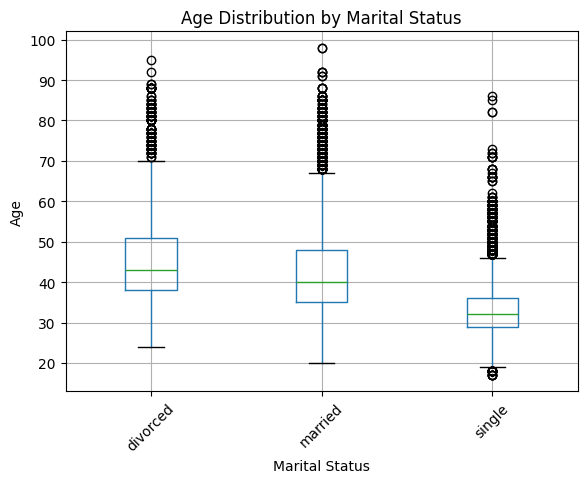

In [394]:
plt.figure(figsize=(8,5))
df.boxplot(column="age", by="marital_status", rot=45)
plt.title("Age Distribution by Marital Status")
plt.suptitle("")
plt.xlabel("Marital Status")
plt.ylabel("Age")
plt.show()

In [395]:
pd.crosstab(
    df["education_level"],
    df["marital_status"],
    normalize="index"
).round(3) * 100


marital_status,divorced,married,single
education_level,,,
basic_4y,11.7,77.4,10.9
basic_6y,8.0,77.3,14.7
basic_9y,9.4,68.8,21.8
high_school,12.6,54.3,33.2
illiterate,11.1,83.3,5.6
professional_course,12.5,60.3,27.2
university_degree,11.0,52.7,36.3


In [396]:
pd.crosstab(
    df["occupation"],
    df["marital_status"],
    normalize="index"
).round(3) * 100


marital_status,divorced,married,single
occupation,,,
admin,12.2,50.9,36.9
blue_collar,7.8,72.3,19.8
entrepreneur,12.3,73.7,14.0
housemaid,15.2,73.5,11.3
management,11.3,71.5,17.2
retired,20.1,74.4,5.5
self_employed,9.4,63.8,26.8
services,13.4,57.9,28.7
student,1.0,4.7,94.3


In [397]:
def impute_marital_with_stage(
    df,
    ms_col="marital_status",
    edu_col="education_level",
    agegrp_col="age_group",
    occ_col="occupation"
):
    """
    Staged marital_status imputation using:
      Stage A: (education_level, age_group, occupation)
      Stage B: (education_level, age_group)
      Stage C: (age_group)
      Stage D: global mode

    Adds a new column: marital_impute_stage ('A','B','C','D')
    """
    out = df.copy()

    # Track original missing values
    orig_missing = out[ms_col].isna()

    # Clean text columns
    for c in [ms_col, edu_col, agegrp_col, occ_col]:
        if c in out.columns:
            out[c] = (
                out[c]
                .astype(str)
                .str.strip()
                .str.lower()
                .replace({"": np.nan, "nan": np.nan})
            )

    before_missing = int(out[ms_col].isna().sum())
    out["marital_impute_stage"] = np.nan

    def gmode(s: pd.Series):
        s = s.dropna()
        return s.mode().iloc[0] if not s.empty else np.nan

    report = {}

    # ---------- Stage A: (education_level, age_group, occupation) ----------
    missing = out[ms_col].isna()
    if missing.sum() > 0:
        modA = (
            out.groupby([edu_col, agegrp_col, occ_col])[ms_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modA, on=[edu_col, agegrp_col, occ_col], how="left")
        fillA = missing & out["__mod"].notna()
        out.loc[fillA, ms_col] = out.loc[fillA, "__mod"]
        out.loc[fillA & orig_missing, "marital_impute_stage"] = "A"
        out = out.drop(columns="__mod")
        report["filled_stage_A"] = int(fillA.sum())
    else:
        report["filled_stage_A"] = 0

    # ---------- Stage B: (education_level, age_group) ----------
    missing = out[ms_col].isna()
    if missing.sum() > 0:
        modB = (
            out.groupby([edu_col, agegrp_col])[ms_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modB, on=[edu_col, agegrp_col], how="left")
        fillB = missing & out["__mod"].notna()
        out.loc[fillB, ms_col] = out.loc[fillB, "__mod"]
        out.loc[fillB & orig_missing, "marital_impute_stage"] = "B"
        out = out.drop(columns="__mod")
        report["filled_stage_B"] = int(fillB.sum())
    else:
        report["filled_stage_B"] = 0

    # ---------- Stage C: (age_group only) ----------
    missing = out[ms_col].isna()
    if missing.sum() > 0:
        modC = (
            out.groupby([agegrp_col])[ms_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modC, on=[agegrp_col], how="left")
        fillC = missing & out["__mod"].notna()
        out.loc[fillC, ms_col] = out.loc[fillC, "__mod"]
        out.loc[fillC & orig_missing, "marital_impute_stage"] = "C"
        out = out.drop(columns="__mod")
        report["filled_stage_C"] = int(fillC.sum())
    else:
        report["filled_stage_C"] = 0

    # ---------- Stage D: global mode ----------
    missing = out[ms_col].isna()
    if missing.sum() > 0:
        global_mod = gmode(out[ms_col])
        out.loc[missing, ms_col] = global_mod
        out.loc[missing & orig_missing, "marital_impute_stage"] = "D"
        report["filled_stage_D"] = int(missing.sum())
    else:
        report["filled_stage_D"] = 0

    after_missing = int(out[ms_col].isna().sum())
    report["marital_missing_before"] = before_missing
    report["marital_missing_after"] = after_missing

    return out, report, orig_missing


In [398]:
df, ms_report, ms_orig_missing = impute_marital_with_stage(df)

print("=== Marital Status Imputation Report ===")
for k, v in ms_report.items():
    print(k, ":", v)

=== Marital Status Imputation Report ===
filled_stage_A : 71
filled_stage_B : 0
filled_stage_C : 9
filled_stage_D : 0
marital_missing_before : 80
marital_missing_after : 0


C:\Users\tan98\AppData\Local\Temp\ipykernel_32708\2668240902.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[fillA & orig_missing, "marital_impute_stage"] = "A"


In [399]:
assigned_ms = df.loc[ms_orig_missing, 
    ["age", "age_group", "education_level", "marital_status", "marital_impute_stage"]
]

print(assigned_ms.head(20))

      age age_group      education_level marital_status marital_impute_stage
503    37     35-44    university_degree        married                    A
913    36     35-44    university_degree        married                    A
1051   58     55-64    university_degree        married                    A
1112   29     25-34          high_school         single                    A
2424   27     25-34          high_school         single                    A
3424   25     25-34    university_degree         single                    A
3508   30     25-34             basic_9y         single                    A
4922   37     35-44    university_degree        married                    A
5008   66       65+             basic_9y        married                    A
5076   31     25-34  professional_course        married                    A
5105   45     45-54                  NaN        married                    C
5532   35     35-44             basic_9y        married                    A

Education level

<Figure size 800x500 with 0 Axes>

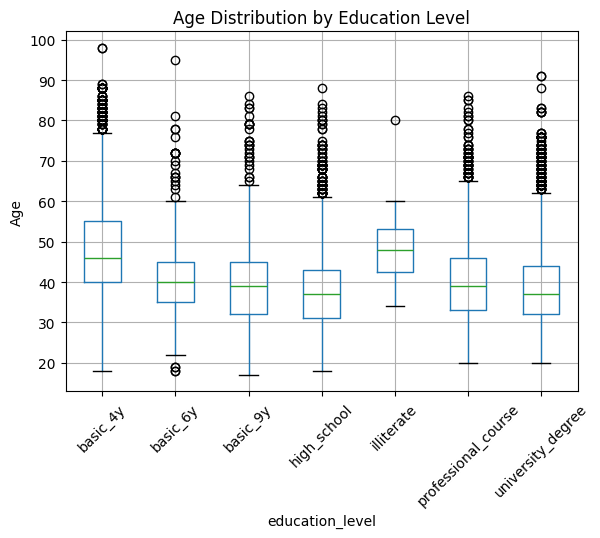

In [400]:
plt.figure(figsize=(8,5))
df.boxplot(column="age", by="education_level", rot=45)
plt.title("Age Distribution by Education Level")
plt.suptitle("")
plt.ylabel("Age")
plt.show()

In [401]:
pd.crosstab(
    df["occupation"],
    df["education_level"],
    normalize="index"
).round(3) * 100


education_level,basic_4y,basic_6y,basic_9y,high_school,illiterate,professional_course,university_degree
occupation,,,,,,,
admin,0.8,1.5,4.9,32.8,0.0,3.5,56.5
blue_collar,26.5,16.3,41.1,9.9,0.1,5.1,1.1
entrepreneur,9.8,5.1,15.0,16.7,0.1,9.6,43.6
housemaid,46.6,7.6,9.2,17.1,0.1,5.8,13.7
management,3.6,3.0,5.9,10.6,0.0,3.2,73.7
retired,37.4,4.7,8.8,16.8,0.2,14.8,17.4
self_employed,6.7,1.8,15.8,8.5,0.2,12.1,55.0
services,3.5,5.9,10.2,70.2,0.0,5.7,4.5
student,3.7,1.8,14.0,50.4,0.0,6.1,24.0


In [402]:
pd.crosstab(
    df["marital_status"],
    df["education_level"],
    normalize="index"
).round(3) * 100


education_level,basic_4y,basic_6y,basic_9y,high_school,illiterate,professional_course,university_degree
marital_status,,,,,,,
divorced,11.1,4.1,12.8,27.0,0.0,14.8,30.2
married,13.5,7.4,17.4,21.6,0.1,13.2,26.8
single,4.1,3.0,11.9,28.4,0.0,12.8,39.8


In [403]:
def impute_education_with_stage(
    df,
    edu_col="education_level",
    occ_col="occupation",
    agegrp_col="age_group",
    ms_col="marital_status"
):
    """
    Impute education_level using 5 stages:
      A: (occupation, age_group, marital_status)
      B: (occupation, age_group)
      C: (occupation)
      D: (age_group)
      E: global mode
    """

    out = df.copy()
    orig_missing = out[edu_col].isna()

    # clean text columns
    for c in [edu_col, occ_col, agegrp_col, ms_col]:
        out[c] = (
            out[c]
            .astype(str)
            .str.lower()
            .str.strip()
            .replace({"": np.nan, "nan": np.nan})
        )

    out["education_impute_stage"] = np.nan

    def gmode(s):
        s = s.dropna()
        return s.mode().iloc[0] if not s.empty else np.nan

    report = {}
    before_missing = int(out[edu_col].isna().sum())

    # ---------- Stage A: (occupation, age_group, marital_status) ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        modA = (
            out.groupby([occ_col, agegrp_col, ms_col])[edu_col]
               .apply(gmode).rename("__mod").reset_index()
        )
        out = out.merge(modA, on=[occ_col, agegrp_col, ms_col], how="left")
        fillA = missing & out["__mod"].notna()
        out.loc[fillA, edu_col] = out.loc[fillA, "__mod"]
        out.loc[fillA & orig_missing, "education_impute_stage"] = "A"
        out.drop(columns="__mod", inplace=True)
        report["stage_A"] = int(fillA.sum())
    else:
        report["stage_A"] = 0

    # ---------- Stage B: (occupation, age_group) ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        modB = (
            out.groupby([occ_col, agegrp_col])[edu_col]
               .apply(gmode).rename("__mod").reset_index()
        )
        out = out.merge(modB, on=[occ_col, agegrp_col], how="left")
        fillB = missing & out["__mod"].notna()
        out.loc[fillB, edu_col] = out.loc[fillB, "__mod"]
        out.loc[fillB & orig_missing, "education_impute_stage"] = "B"
        out.drop(columns="__mod", inplace=True)
        report["stage_B"] = int(fillB.sum())
    else:
        report["stage_B"] = 0

    # ---------- Stage C: (occupation only) ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        modC = (
            out.groupby([occ_col])[edu_col]
               .apply(gmode).rename("__mod").reset_index()
        )
        out = out.merge(modC, on=[occ_col], how="left")
        fillC = missing & out["__mod"].notna()
        out.loc[fillC, edu_col] = out.loc[fillC, "__mod"]
        out.loc[fillC & orig_missing, "education_impute_stage"] = "C"
        out.drop(columns="__mod", inplace=True)
        report["stage_C"] = int(fillC.sum())
    else:
        report["stage_C"] = 0

    # ---------- Stage D: (age_group only) ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        modD = (
            out.groupby([agegrp_col])[edu_col]
               .apply(gmode).rename("__mod").reset_index()
        )
        out = out.merge(modD, on=[agegrp_col], how="left")
        fillD = missing & out["__mod"].notna()
        out.loc[fillD, edu_col] = out.loc[fillD, "__mod"]
        out.loc[fillD & orig_missing, "education_impute_stage"] = "D"
        out.drop(columns="__mod", inplace=True)
        report["stage_D"] = int(fillD.sum())
    else:
        report["stage_D"] = 0

    # ---------- Stage E: global mode ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        global_mod = gmode(out[edu_col])
        out.loc[missing, edu_col] = global_mod
        out.loc[missing & orig_missing, "education_impute_stage"] = "E"
        report["stage_E"] = int(missing.sum())
    else:
        report["stage_E"] = 0

    report["before_missing"] = before_missing
    report["after_missing"] = int(out[edu_col].isna().sum())

    return out, report, orig_missing


In [404]:
df, edu_report2, edu_missing2 = impute_education_with_stage(df)
edu_report2


C:\Users\tan98\AppData\Local\Temp\ipykernel_32708\2026168518.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[fillA & orig_missing, "education_impute_stage"] = "A"


{'stage_A': 1726,
 'stage_B': 0,
 'stage_C': 5,
 'stage_D': 0,
 'stage_E': 0,
 'before_missing': 1731,
 'after_missing': 0}

In [405]:
df.loc[
    edu_missing2,
    ["age", "age_group", "occupation", "marital_status",
     "education_level", "education_impute_stage"]
]


,age,age_group,occupation,marital_status,education_level,education_impute_stage
1,55,55-64,admin,married,university_degree,A
41,38,35-44,blue_collar,married,basic_9y,A
75,30,25-34,blue_collar,single,basic_9y,A
111,38,35-44,admin,married,university_degree,A
122,54,45-54,blue_collar,married,basic_4y,A
...,...,...,...,...,...,...
41137,47,45-54,services,married,high_school,A
41153,34,25-34,blue_collar,married,basic_9y,A
41175,50,45-54,services,married,high_school,A
41177,58,55-64,management,married,university_degree,A


Credit_Default imputation

In [406]:
df["credit_default"] = df["credit_default"].fillna("no")

In [407]:
df["credit_default"].value_counts(dropna=False)

credit_default
no     41185
yes        3
Name: count, dtype: int64

Housing Loan Imputation

<Figure size 1000x500 with 0 Axes>

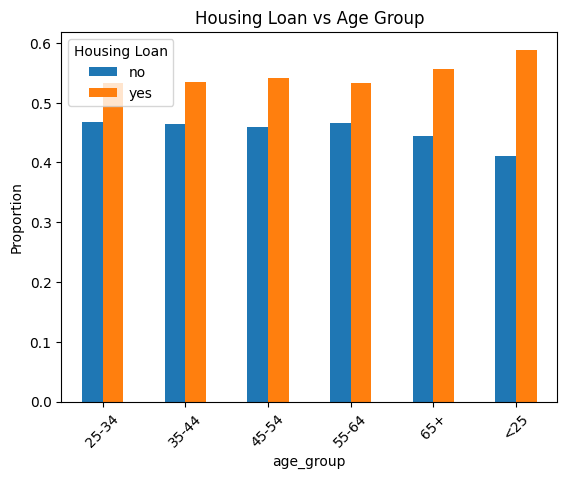

In [408]:
plt.figure(figsize=(10,5))
df.groupby("age_group")["housing_loan"].value_counts(normalize=True).unstack().plot(kind="bar")
plt.title("Housing Loan vs Age Group")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Housing Loan")
plt.show()


<Figure size 800x500 with 0 Axes>

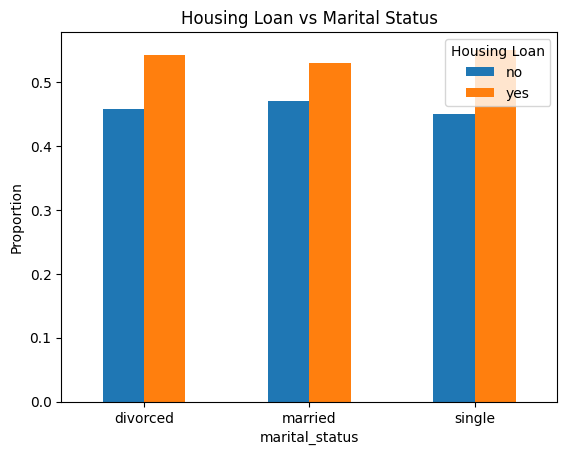

In [409]:
plt.figure(figsize=(8,5))
df.groupby("marital_status")["housing_loan"].value_counts(normalize=True).unstack().plot(kind="bar")
plt.title("Housing Loan vs Marital Status")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Housing Loan")
plt.show()


<Figure size 1200x600 with 0 Axes>

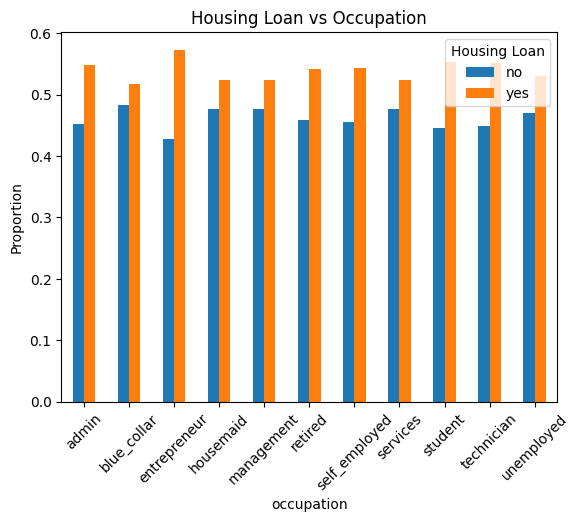

In [410]:
plt.figure(figsize=(12,6))
df.groupby("occupation")["housing_loan"].value_counts(normalize=True).unstack().plot(kind="bar")
plt.title("Housing Loan vs Occupation")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Housing Loan")
plt.show()


In [411]:
df["housing_loan"] = df["housing_loan"].fillna("unknown")

In [412]:
df["housing_loan"].value_counts(dropna=False)

housing_loan
unknown    25182
yes         8595
no          7411
Name: count, dtype: int64

Personal Loan Imputation

<Figure size 1000x500 with 0 Axes>

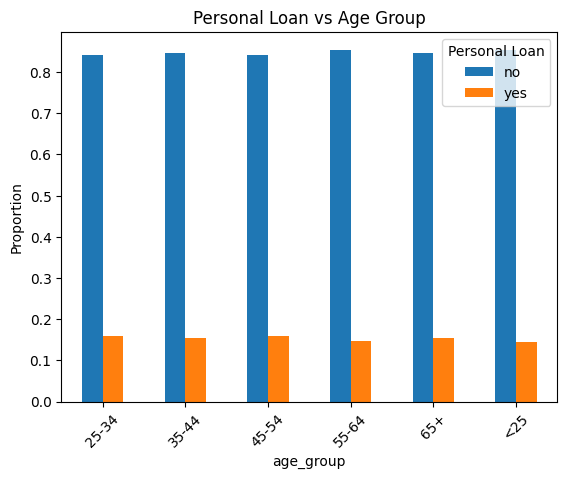

In [413]:
plt.figure(figsize=(10,5))
df.groupby("age_group")["personal_loan"].value_counts(normalize=True).unstack().plot(kind="bar")
plt.title("Personal Loan vs Age Group")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Personal Loan")
plt.show()


<Figure size 800x500 with 0 Axes>

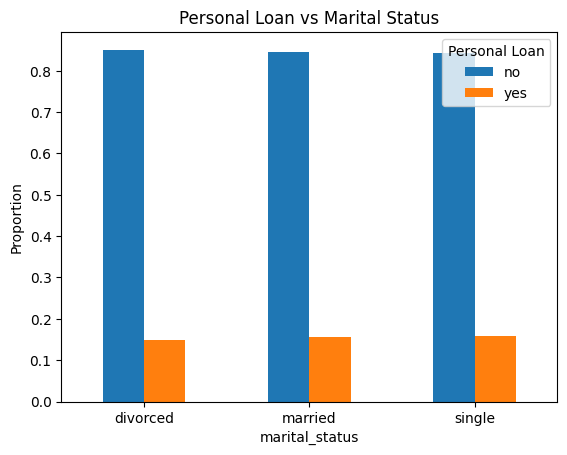

In [414]:
plt.figure(figsize=(8,5))
df.groupby("marital_status")["personal_loan"].value_counts(normalize=True).unstack().plot(kind="bar")
plt.title("Personal Loan vs Marital Status")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Personal Loan")
plt.show()


<Figure size 1200x600 with 0 Axes>

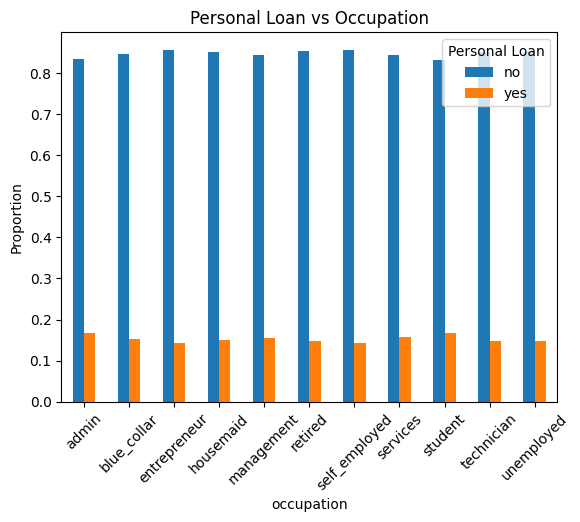

In [415]:
plt.figure(figsize=(12,6))
df.groupby("occupation")["personal_loan"].value_counts(normalize=True).unstack().plot(kind="bar")
plt.title("Personal Loan vs Occupation")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Personal Loan")
plt.show()


<Figure size 1200x500 with 0 Axes>

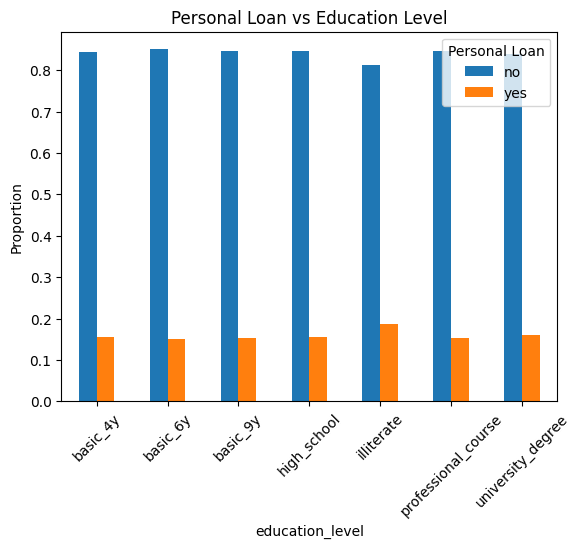

In [416]:
plt.figure(figsize=(12,5))
df.groupby("education_level")["personal_loan"].value_counts(normalize=True).unstack().plot(kind="bar")
plt.title("Personal Loan vs Education Level")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Personal Loan")
plt.show()


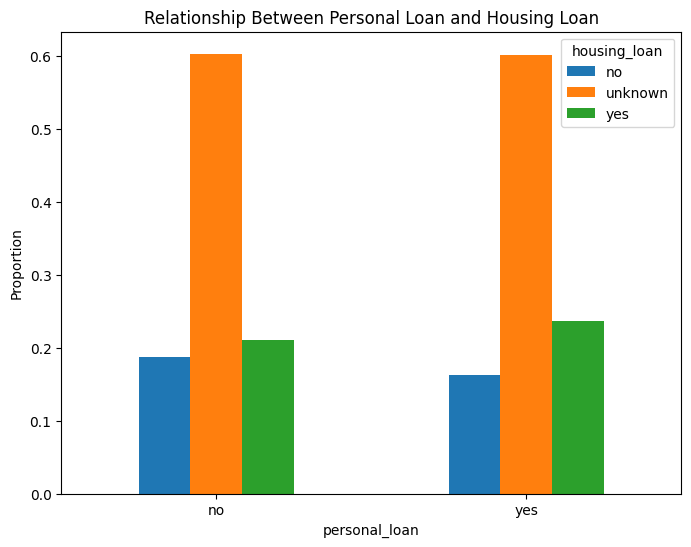

In [417]:
pd.crosstab(df["personal_loan"], df["housing_loan"], normalize="index").plot(kind="bar", figsize=(8,6))
plt.title("Relationship Between Personal Loan and Housing Loan")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()


In [418]:
df["personal_loan"] = df["personal_loan"].fillna("unknown")

In [419]:
df["personal_loan"].value_counts(dropna=False)

personal_loan
no         30532
yes         5633
unknown     5023
Name: count, dtype: int64

Univariate Analysis

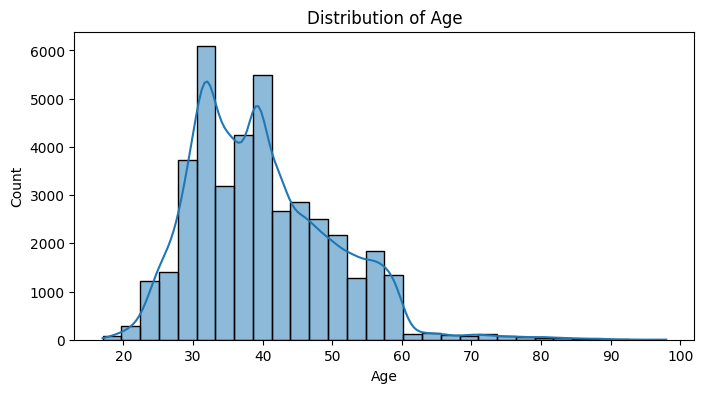

In [420]:
plt.figure(figsize=(8,4))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [426]:
def countplot_with_labels(column):
    plt.figure(figsize=(10,4))
    ax = sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    # Add labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{height}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom'
        )

    plt.show()


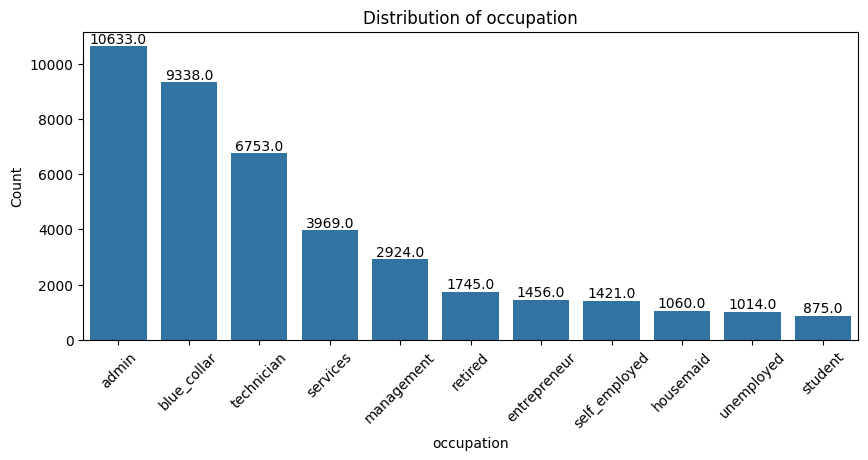

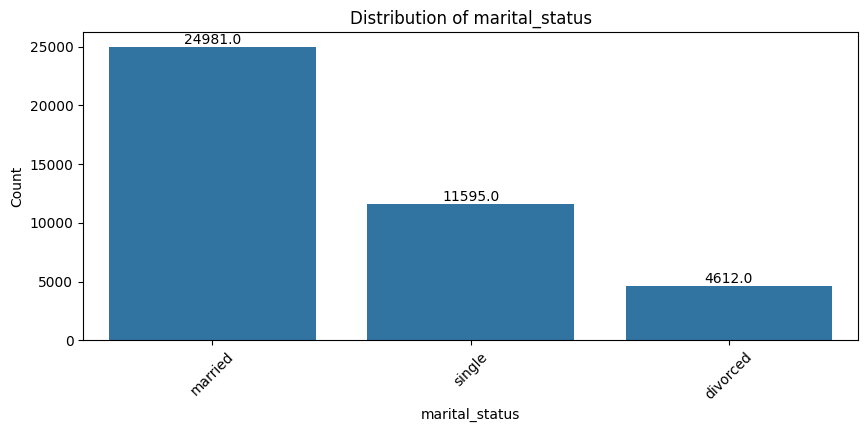

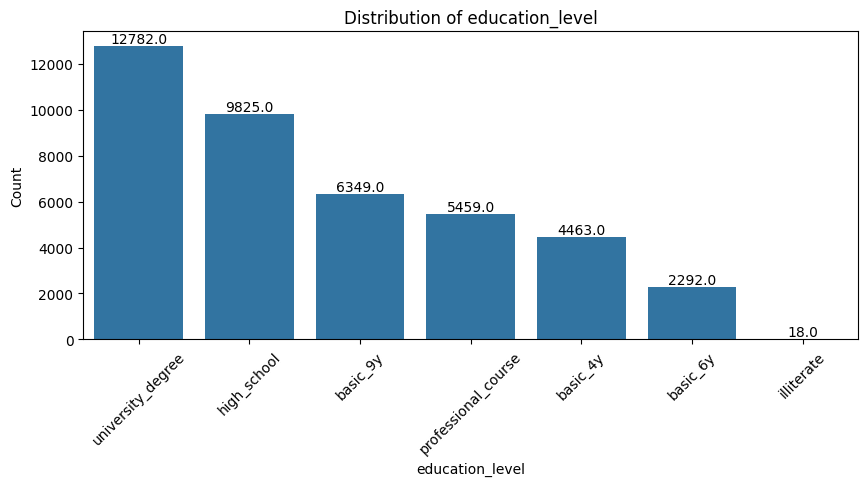

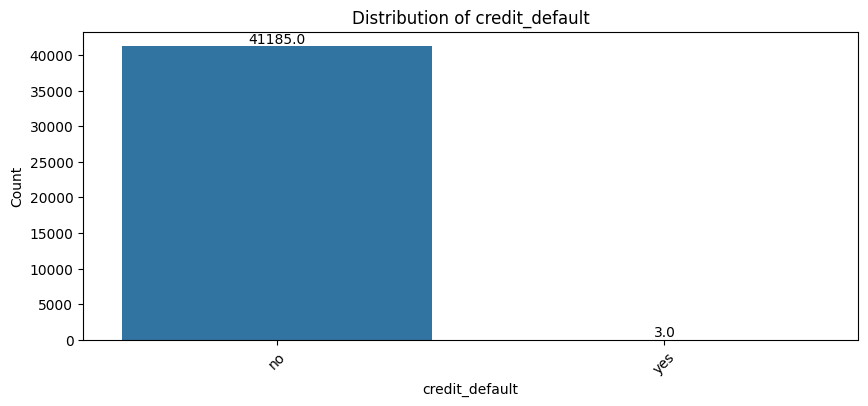

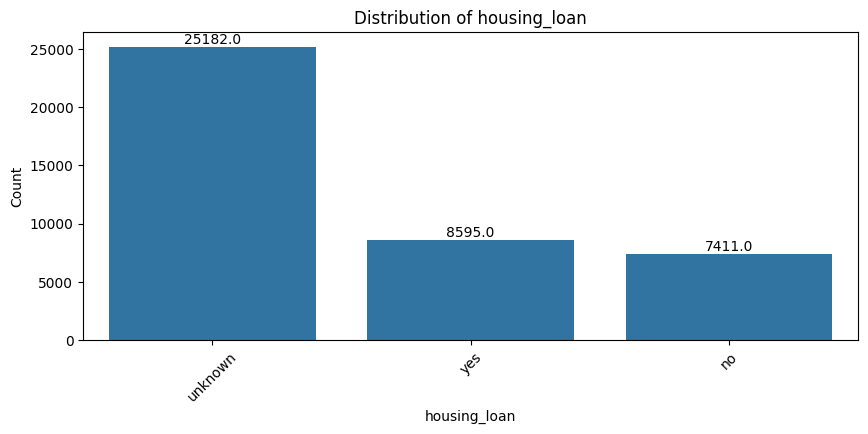

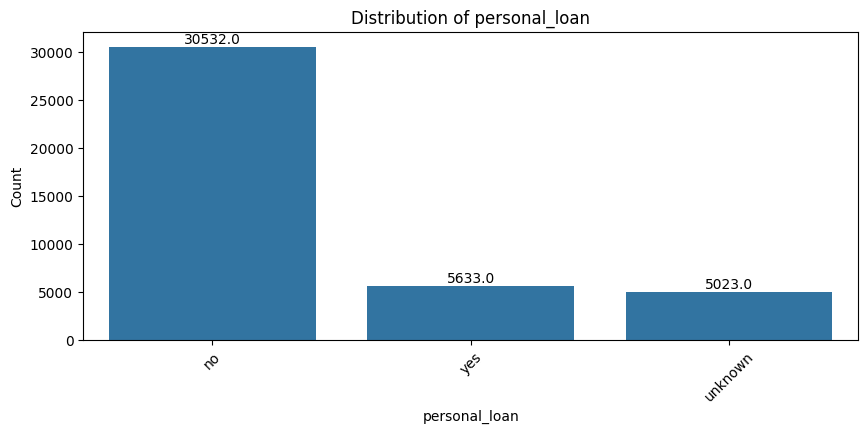

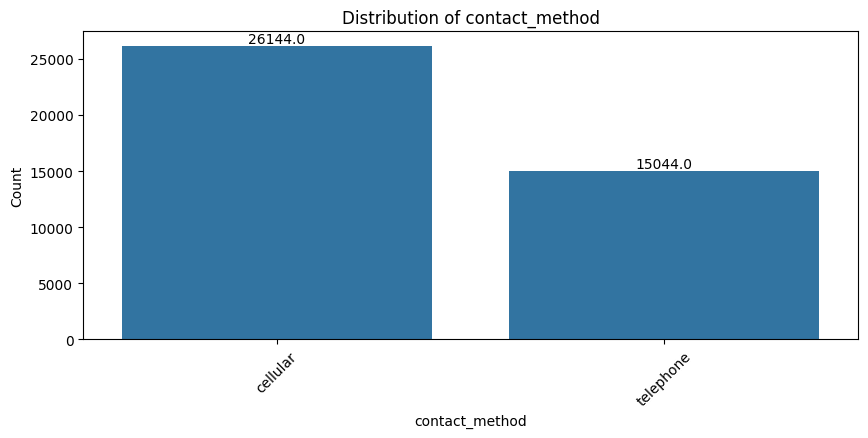

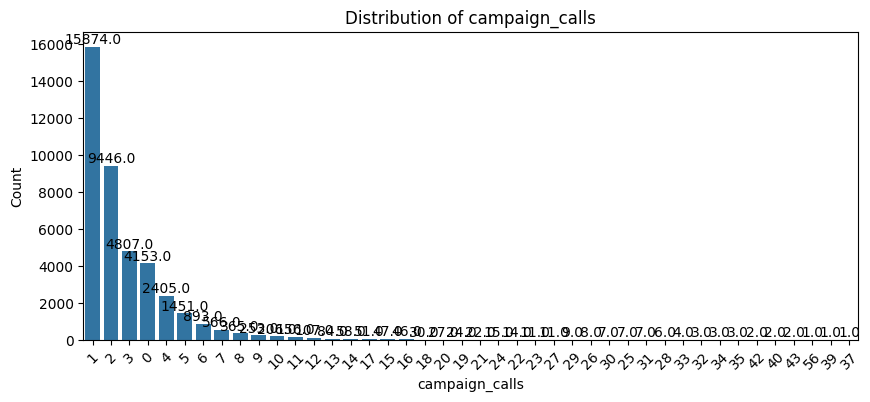

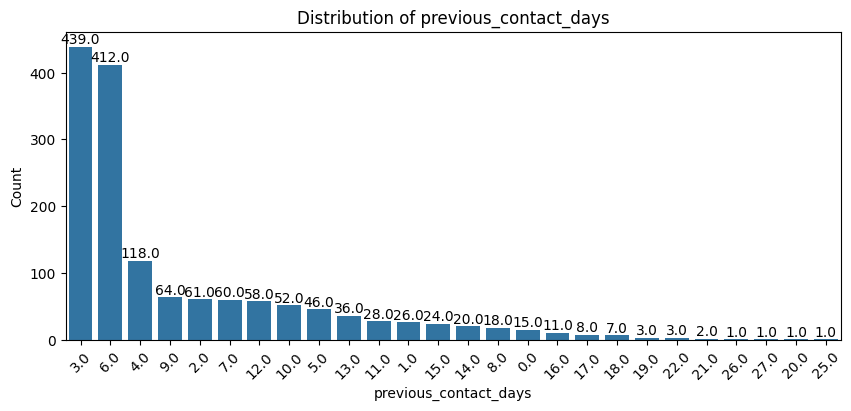

In [430]:
countplot_with_labels("occupation")
countplot_with_labels("marital_status")
countplot_with_labels("education_level")
countplot_with_labels("credit_default")
countplot_with_labels("housing_loan")
countplot_with_labels("personal_loan")
countplot_with_labels("contact_method")
countplot_with_labels("campaign_calls")
countplot_with_labels("previous_contact_days")

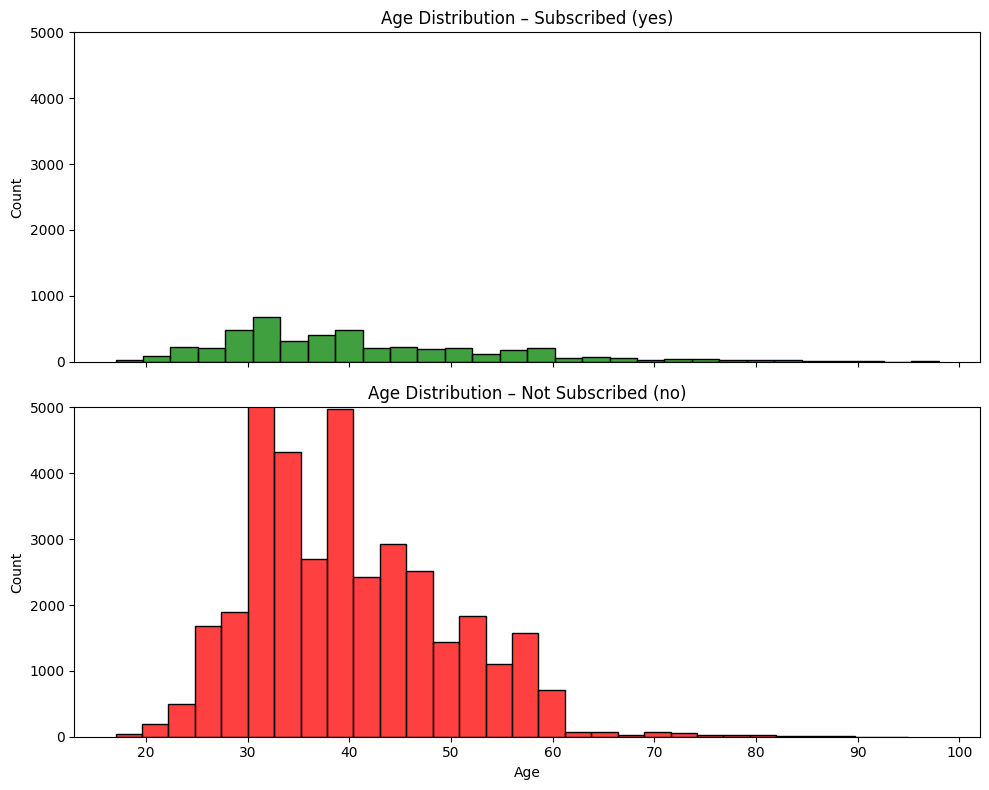

In [438]:
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

# YES histogram
sns.histplot(
    df[df["subscription_status"] == "yes"]["age"],
    bins=30,
    color="green",
    ax=axes[0]
)
axes[0].set_title("Age Distribution – Subscribed (yes)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 5000)     # <-- FIXED Y LIMIT

# NO histogram
sns.histplot(
    df[df["subscription_status"] == "no"]["age"],
    bins=30,
    color="red",
    ax=axes[1]
)
axes[1].set_title("Age Distribution – Not Subscribed (no)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 5000)     # <-- FIXED Y LIMIT

plt.tight_layout()
plt.show()


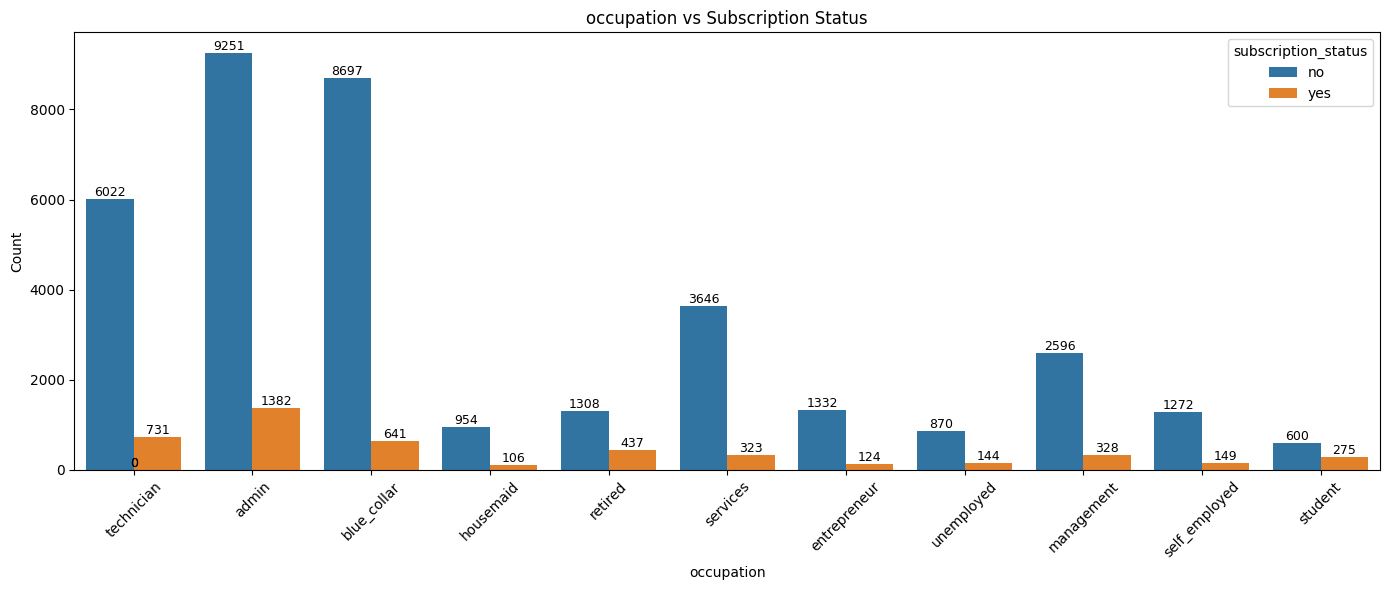

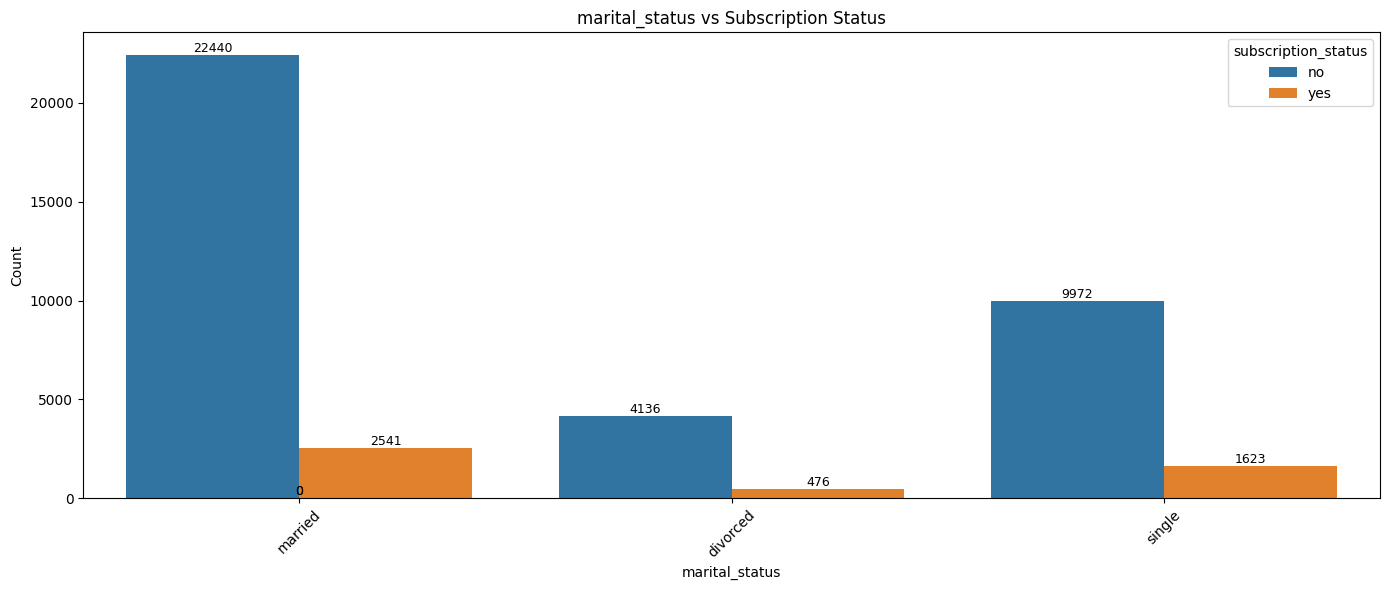

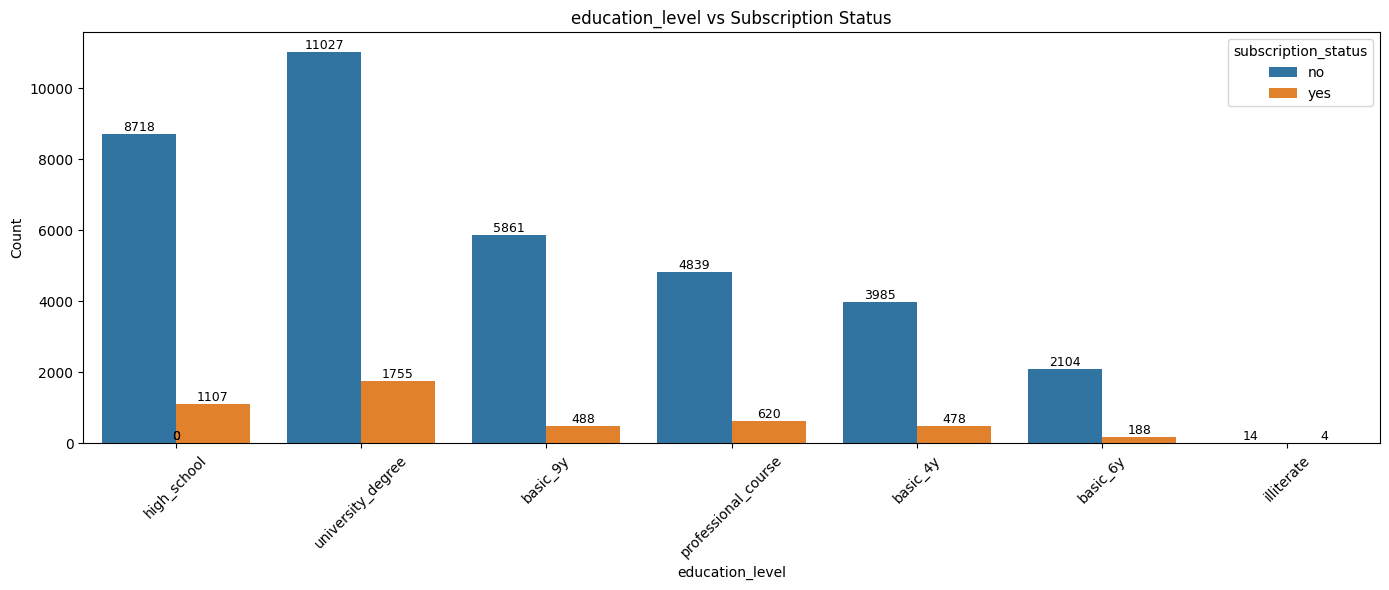

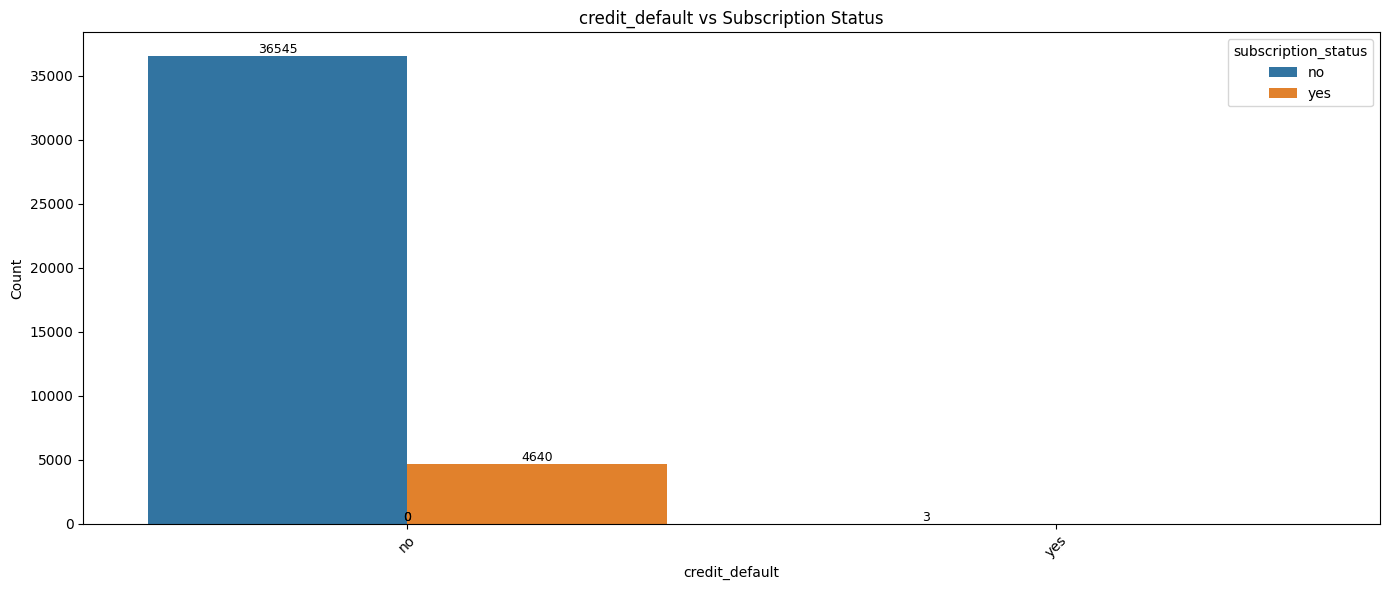

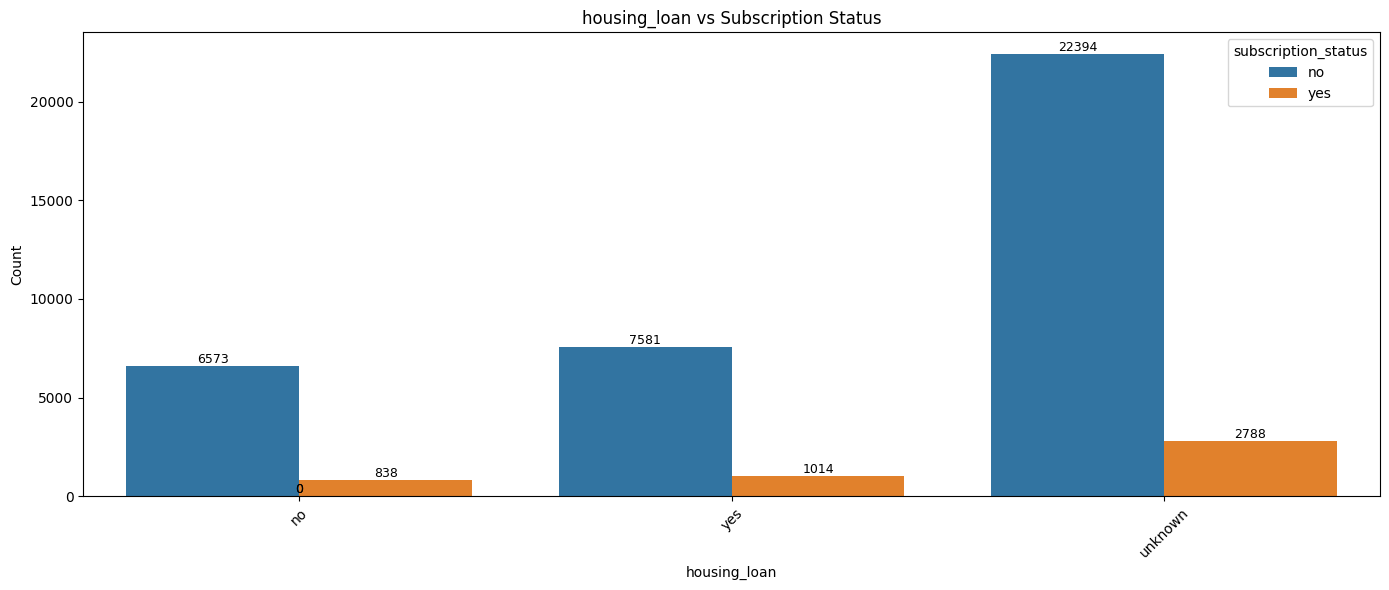

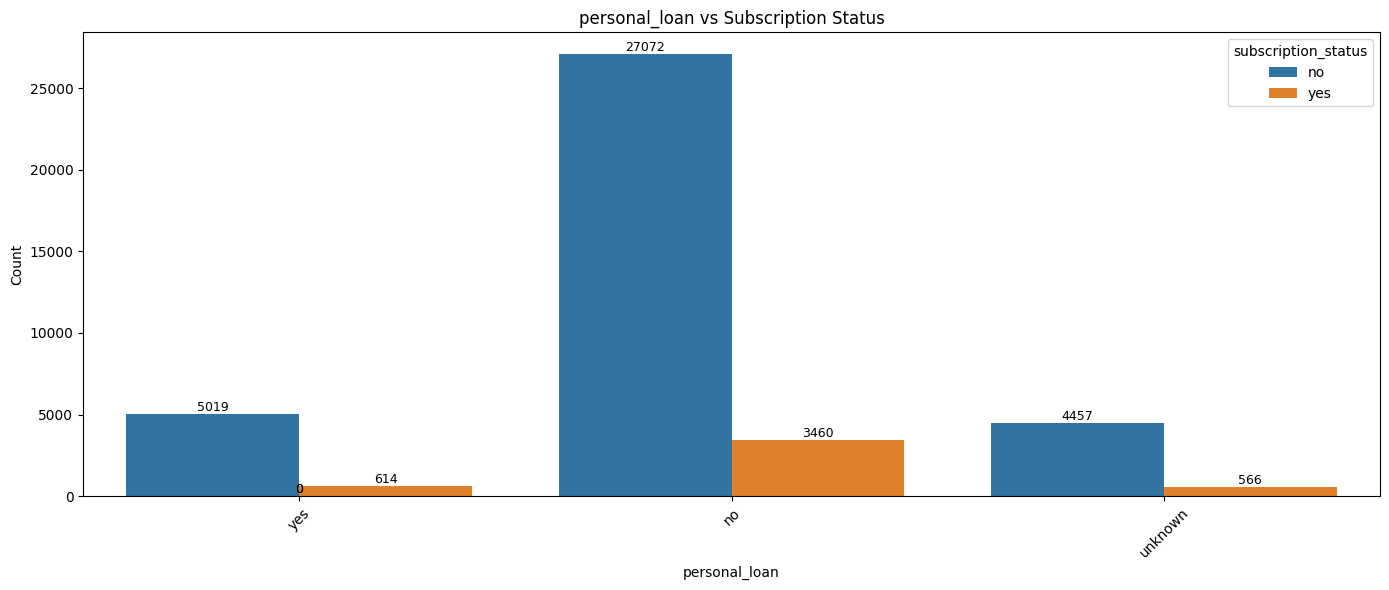

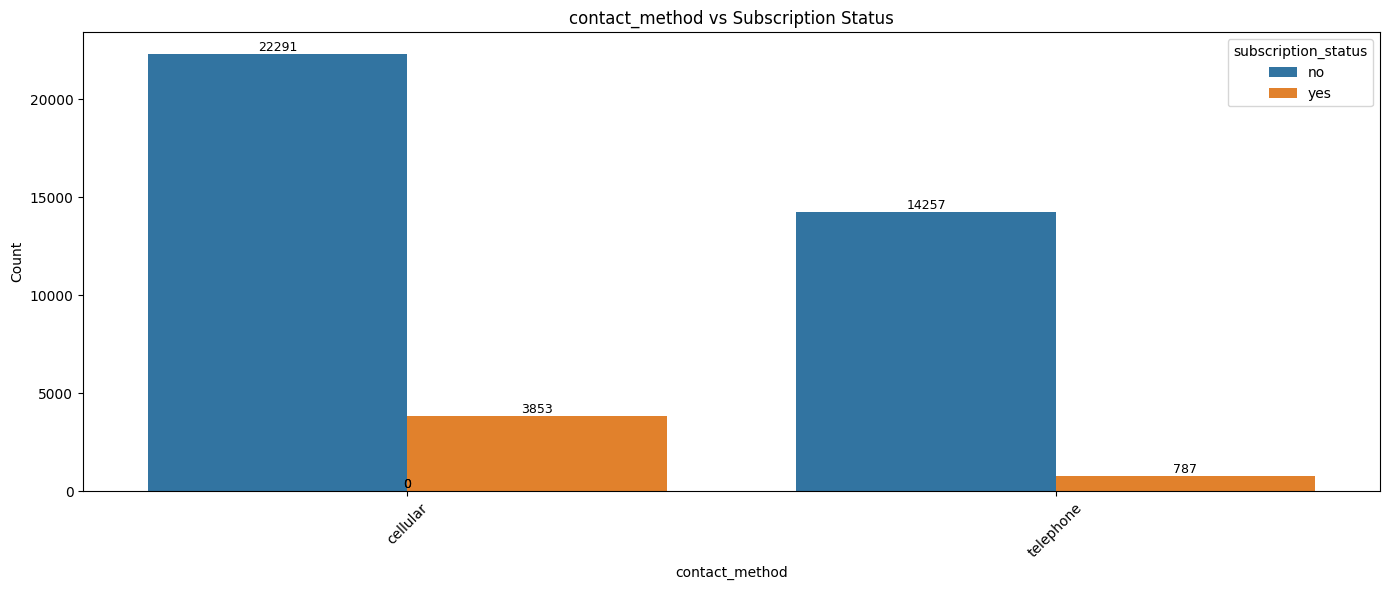

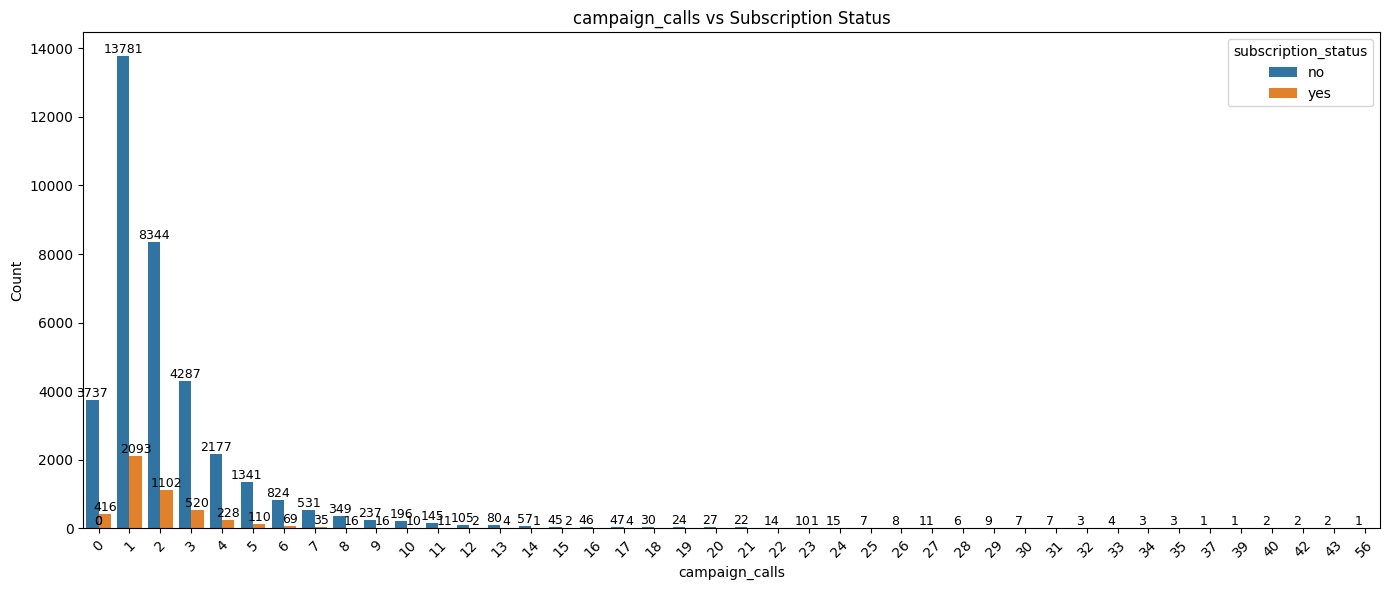

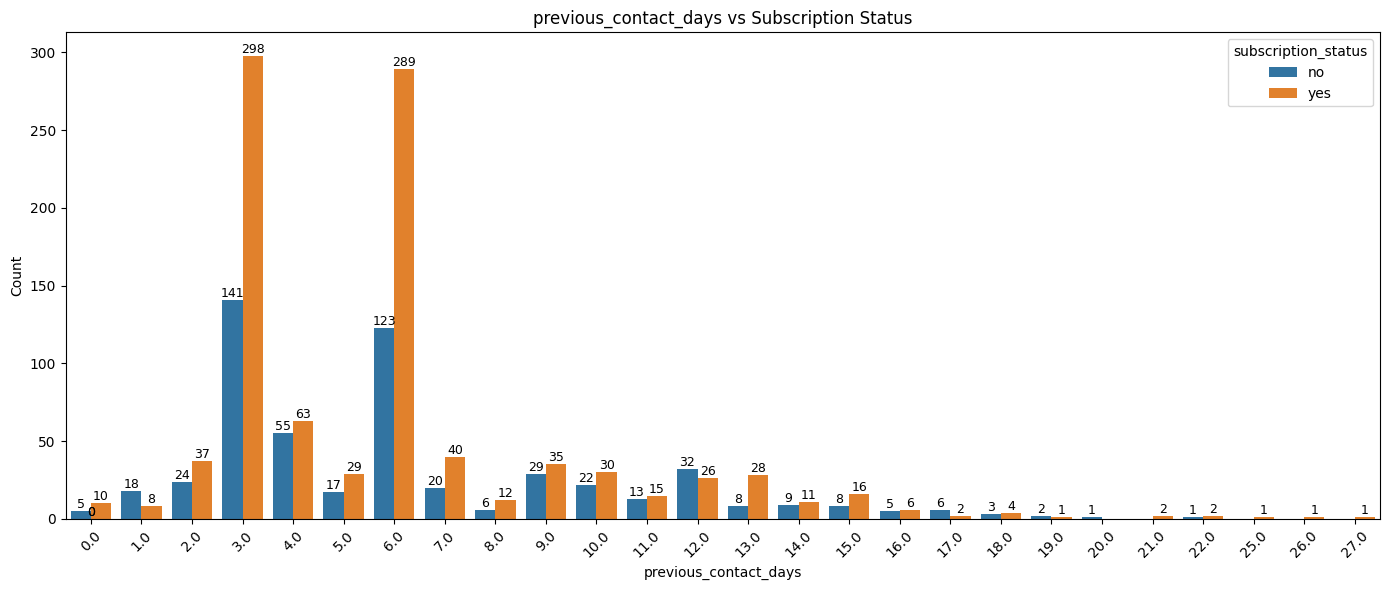

In [454]:
cat_cols = [
    'occupation', 'marital_status', 'education_level', 'credit_default',
    'housing_loan', 'personal_loan', 'contact_method',
    'campaign_calls', 'previous_contact_days'
]

for c in cat_cols:
    plt.figure(figsize=(14,6))   # <-- wider chart

    ax = sns.countplot(data=df, x=c, hue='subscription_status')

    # Rotate labels if too long
    plt.xticks(rotation=45)

    plt.title(f"{c} vs Subscription Status")
    plt.xlabel(c)
    plt.ylabel("Count")

    # ---- ADD LABELS ON TOP OF EACH BAR ----
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width()/2., height),
            ha='center', va='bottom',
            fontsize=9
        )
    
    plt.tight_layout()
    plt.show()


Feature Engineering

In [455]:
# Working copy of cleaned EDA dataframe
df_model = df.copy()


In [456]:
# Binary encode target
df_model["subscription_status_encoded"] = df_model["subscription_status"].map({
    "no": 0,
    "yes": 1
})

In [457]:
df_model["credit_default_enc"] = df_model["credit_default"].map({"no": 0, "yes": 1})

In [458]:
df_model["housing_loan_enc"] = df_model["housing_loan"].map({
    "no": 0, "yes": 1, "unknown": -1
})

In [459]:
df_model["personal_loan_enc"] = df_model["personal_loan"].map({
    "no": 0, "yes": 1, "unknown": -1
})

In [460]:
df_model["age_group"] = pd.cut(
    df_model["age"],
    bins=[16, 25, 35, 50, 65, np.inf],
    labels=["17-25", "26-35", "36-50", "51-65", "65+"]
)

In [461]:
df_model["campaign_calls"] = pd.to_numeric(df_model["campaign_calls"], errors="coerce")
df_model["previous_contact_days"] = pd.to_numeric(df_model["previous_contact_days"], errors="coerce")

df_model["previous_contact_flag"] = df_model["previous_contact_days"].notna().astype(int)

df_model["contact_intensity"] = df_model["campaign_calls"] / (df_model["previous_contact_days"].fillna(0) + 1)


In [463]:
df_model["education_level"] = (
    df_model["education_level"]
    .astype(str).str.lower().str.strip()
)

higher_edu = {
    "university_degree", "university", "tertiary",
    "professional_course", "professional"
}

df_model["is_higher_edu"] = df_model["education_level"].isin(higher_edu).astype(int)

loan_yes_df = pd.DataFrame({
    "housing": (df_model["housing_loan"] == "yes").astype(int),
    "personal": (df_model["personal_loan"] == "yes").astype(int),
    "default": (df_model["credit_default"] == "yes").astype(int),
})
df_model["loan_burden"] = loan_yes_df.sum(axis=1)


In [464]:
cat_cols = [
    "occupation", "marital_status", "education_level",
    "contact_method", "age_group"
]

for c in cat_cols:
    df_model[c] = df_model[c].astype(str).str.lower().str.strip()

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)


In [465]:
drop_cols = [
    "subscription_status",
    "credit_default",
    "housing_loan",
    "personal_loan",
]

df_model = df_model.drop(columns=drop_cols, errors="ignore")

X = df_model.drop(columns=["subscription_status_encoded"])
y = df_model["subscription_status_encoded"]


In [466]:
numeric_df = df_model.select_dtypes(include=['int64', 'float64'])
numeric_df.head()


,client_id,age,campaign_calls,previous_contact_days,subscription_status_encoded,credit_default_enc,housing_loan_enc,personal_loan_enc,previous_contact_flag,contact_intensity,is_higher_edu,loan_burden
0,32885,57,1,NaN,0,0,0,1,0,1.0,0,1
1,3170,55,2,NaN,0,0,1,0,0,2.0,1,1
2,32207,33,1,NaN,0,0,0,0,0,1.0,0,0
3,9404,36,4,NaN,0,0,0,0,0,4.0,0,0
4,14021,27,2,NaN,0,0,-1,0,0,2.0,0,0


In [468]:
corr = numeric_df.corr()


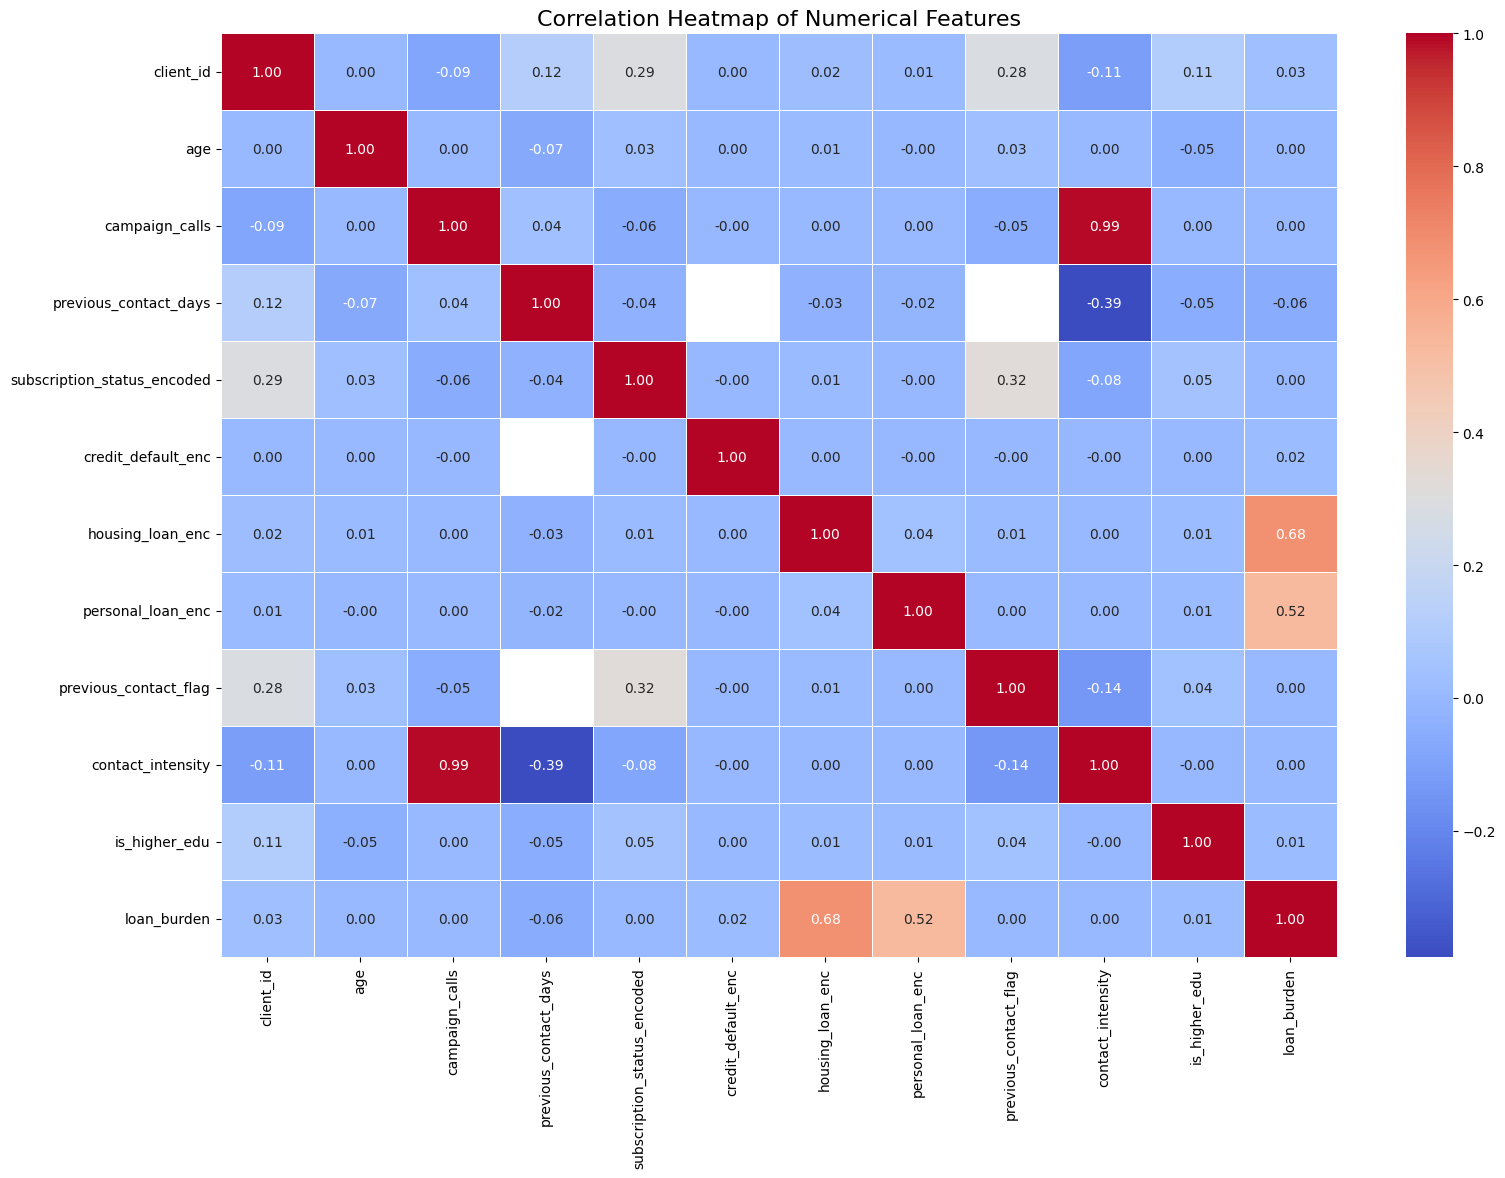

In [469]:
plt.figure(figsize=(18, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=False
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.show()


In [470]:
df_model

,client_id,age,campaign_calls,previous_contact_days,occupation_impute_stage,marital_impute_stage,education_impute_stage,subscription_status_encoded,credit_default_enc,housing_loan_enc,personal_loan_enc,previous_contact_flag,contact_intensity,is_higher_edu,loan_burden,occupation_blue_collar,occupation_entrepreneur,occupation_housemaid,occupation_management,occupation_retired,occupation_self_employed,occupation_services,occupation_student,occupation_technician,occupation_unemployed,marital_status_married,marital_status_single,education_level_basic_6y,education_level_basic_9y,education_level_high_school,education_level_illiterate,education_level_professional_course,education_level_university_degree,contact_method_telephone,age_group_26-35,age_group_36-50,age_group_51-65,age_group_65+
0,32885,57,1,NaN,NaN,NaN,NaN,0,0,0,1,0,1.0,0,1,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,True,False
1,3170,55,2,NaN,C,NaN,A,0,0,1,0,0,2.0,1,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,True,False
2,32207,33,1,NaN,NaN,NaN,NaN,0,0,0,0,0,1.0,0,0,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False
3,9404,36,4,NaN,NaN,NaN,NaN,0,0,0,0,0,4.0,0,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False
4,14021,27,2,NaN,NaN,NaN,NaN,0,0,-1,0,0,2.0,0,0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58,2,NaN,NaN,NaN,NaN,0,0,0,0,0,2.0,1,0,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False
41184,11285,37,1,NaN,NaN,NaN,NaN,0,0,0,0,0,1.0,1,0,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,True,False,False
41185,38159,35,1,4.0,NaN,NaN,NaN,1,0,-1,0,1,0.2,0,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False
41186,861,40,2,NaN,NaN,NaN,NaN,0,0,-1,0,0,2.0,1,0,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,True,False,False


In [472]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [473]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train:", y_train.value_counts())

X_train shape: (32950, 37)
X_test shape: (8238, 37)
y_train: subscription_status_encoded
0    29238
1     3712
Name: count, dtype: int64
